# Eye diagrams — clean vs noisy

Photodetected eye for both regimes, noiseless and with noise, side by side — taken **before the
PD electrical low-pass**, so the photocurrent is the optical intensity |E|² ≥ 0 (no filter
undershoot below zero). Shows the dual nature of the noise: **ASE** beat noise is signal-dependent
(upper levels noisier, and it cannot push the photocurrent negative), **thermal** noise is additive
(uniform, can go negative). Loads the per-regime checkpoints from `results/`. Run from the
`MLforCPO2` folder.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import sys
sys.path.insert(0, "functions")        # local library modules live in functions/

%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.signal import resample_poly

from config import Config
from transmitter import Transmitter, bits_to_symbols
from channel import OpticalChannel
from train import random_bits
from utils import add_awgn, decision_phase_by_separation

%matplotlib inline
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Built fresh per regime in the decision-threshold reference mode (fixed optimum levels: equispaced
# INTENSITY for thermal/A.19, equispaced AMPLITUDE for ASE/A.47) -- no checkpoint needed.
WAVELENGTH = "back-to-back"   # "back-to-back" | "oband" | "cband"
MODULATOR = "linear"          # "linear" | "mzm"
MATCHED_FILTERS = "rrc"       # "rrc" | "freq-rect" | "time-rect"
EBN0 = 20.0                   # Eb/N0 [dB] for the noisy eye

device: cuda


In [2]:
def draw_eye(ax, photocurrent, sps, phase, title, fine_sps=40, skip=100, num_symbols=10000):
    """Overlay symbol windows of the photocurrent to form the eye."""
    fine = resample_poly(photocurrent[:(skip + num_symbols + 8) * sps], fine_sps, sps)
    offset = int(round(phase * fine_sps / sps))
    centers = (skip + np.arange(num_symbols)) * fine_sps + offset
    keep = (centers - fine_sps >= 0) & (centers + fine_sps < len(fine))
    centers = centers[keep]
    window = np.arange(-fine_sps, fine_sps)[:, None] + centers[None, :]
    ax.plot(np.arange(-fine_sps, fine_sps) / fine_sps, fine[window], color=(0.85, 0.33, 0.10, 0.06), lw=0.4)
    ax.axvline(0, color="k", linestyle=":", linewidth=1)
    ax.set_xlim(-1, 1)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Symbol time")
    ax.set_ylabel("Intensity")
    ax.set_title(title)

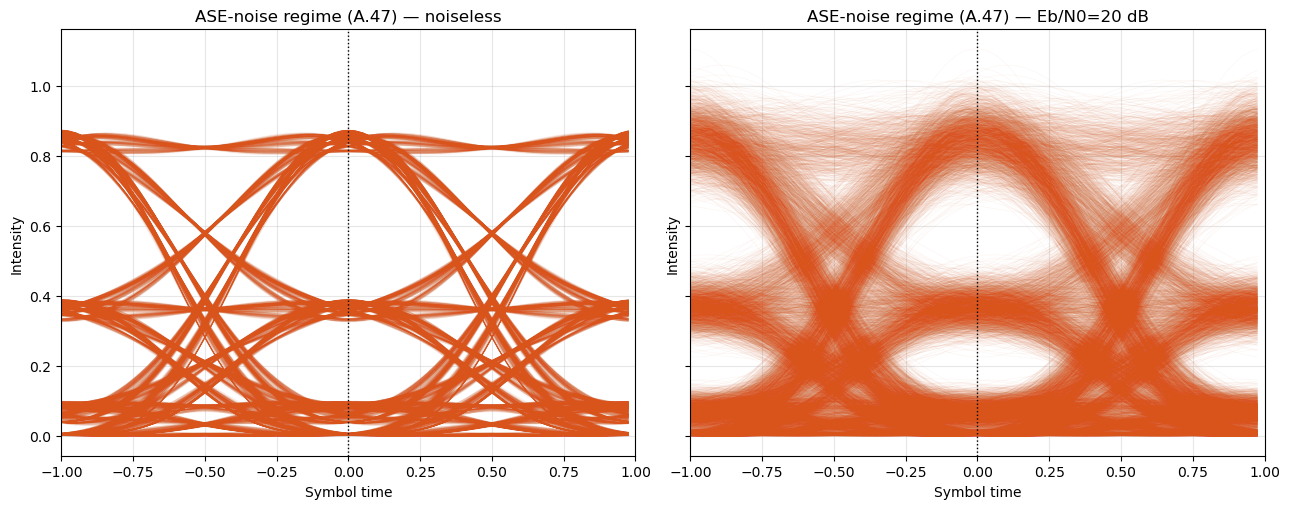

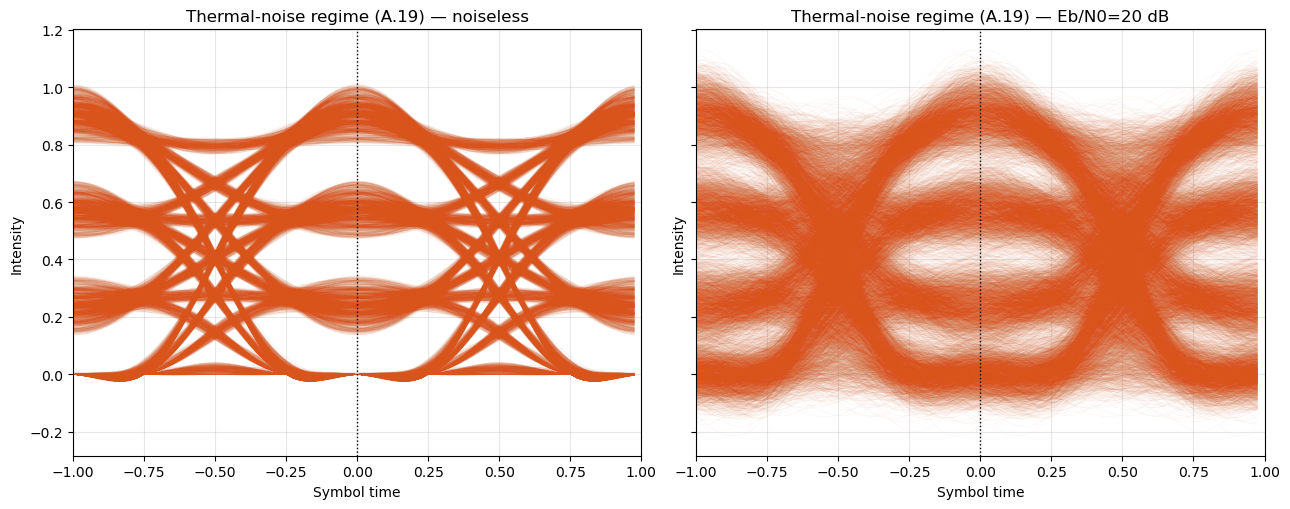

In [3]:
REGIME_LABEL = {"thermal": "Thermal-noise regime (A.19)", "ase": "ASE-noise regime (A.47)"}

for regime in ["ase", "thermal"]:
    cfg = Config()
    cfg.set_wavelength_band(WAVELENGTH)
    cfg.noise_regime = regime
    cfg.modulator = MODULATOR
    cfg.tx_filter = MATCHED_FILTERS
    cfg.rx_filter = MATCHED_FILTERS
    cfg.equalizer = "threshold"                  # fixed optimum reference levels -> no checkpoint needed
    cfg.edge_guard_symbols = 48
    cfg._compute_derived()
    tx = Transmitter(cfg).to(device).eval()      # regime-aware levels (intensity for A.19, amplitude for A.47)
    ch = OpticalChannel(cfg).to(device)
    # eye BEFORE the PD electrical low-pass: photocurrent = optical intensity |E|^2 >= 0 (no undershoot
    # below zero; only thermal noise, added after detection, can go negative)
    ch.pd_filter = torch.nn.Identity()
    sps = cfg.samples_per_symbol_sim
    torch.manual_seed(2)
    bits = random_bits(cfg.bits_per_symbol, 12000, device)
    symbols = bits_to_symbols(bits, cfg.bits_per_symbol).cpu().numpy()
    with torch.no_grad():
        clean = ch(tx(bits)).cpu().numpy()
        if regime == "ase":
            noisy = ch(tx(bits), ase_ebn0_db=EBN0).cpu().numpy()                  # ASE beat noise on the field
        else:
            noisy = add_awgn(ch(tx(bits)), EBN0, cfg.bits_per_symbol, sps).cpu().numpy()   # thermal AWGN at ADC
    phase, _ = decision_phase_by_separation(clean, sps, symbols)

    # sharey -> same y-axis on both panels (set by the noisy one, the wider range)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True)
    draw_eye(axes[0], clean, sps, phase, REGIME_LABEL[regime] + " — noiseless")
    draw_eye(axes[1], noisy, sps, phase, REGIME_LABEL[regime] + f" — Eb/N0={EBN0:.0f} dB")
    fig.tight_layout()
    fig.savefig(os.path.join("results", f"pam4_eye_{regime}.png"), dpi=150, bbox_inches="tight")
    plt.show()